# Cancer Patient Classification using Logistic Regression

This notebook builds a **logistic regression** model to classify breast cancer tumors as **Malignant (M)** or **Benign (B)** using the Wisconsin Breast Cancer diagnostic dataset (`Cancer_Data.csv`).

**Steps covered:**
1. Import libraries
2. Load the dataset
3. Explore the data (EDA)
4. Clean and preprocess the data
5. Encode the target variable
6. Split into train/test sets
7. Feature scaling
8. Train the Logistic Regression model
9. Evaluate the model (accuracy, confusion matrix, classification report, ROC-AUC)
10. Inspect feature importance (model coefficients)
11. Make a prediction on a new/sample patient


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

Place `Cancer_Data.csv` in the same folder as this notebook (or update the path below).

In [2]:
df = pd.read_csv('Cancer_Data.csv')
print("Shape:", df.shape)
df.head()


Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Explore the Data (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
# Summary statistics
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False).head(10)


id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64

diagnosis
B    357
M    212
Name: count, dtype: int64


/tmp/ipykernel_6202/917197764.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette=['#4C72B0', '#DD8452'])


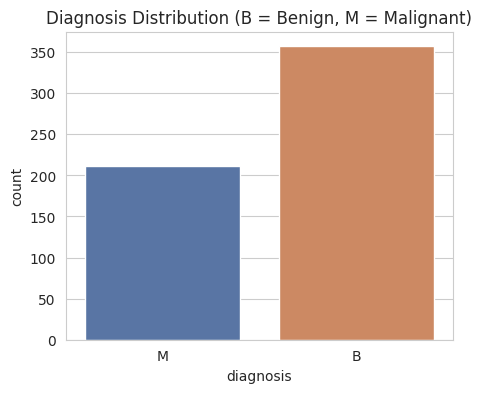

In [6]:
# Target variable distribution
print(df['diagnosis'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Diagnosis Distribution (B = Benign, M = Malignant)')
plt.show()


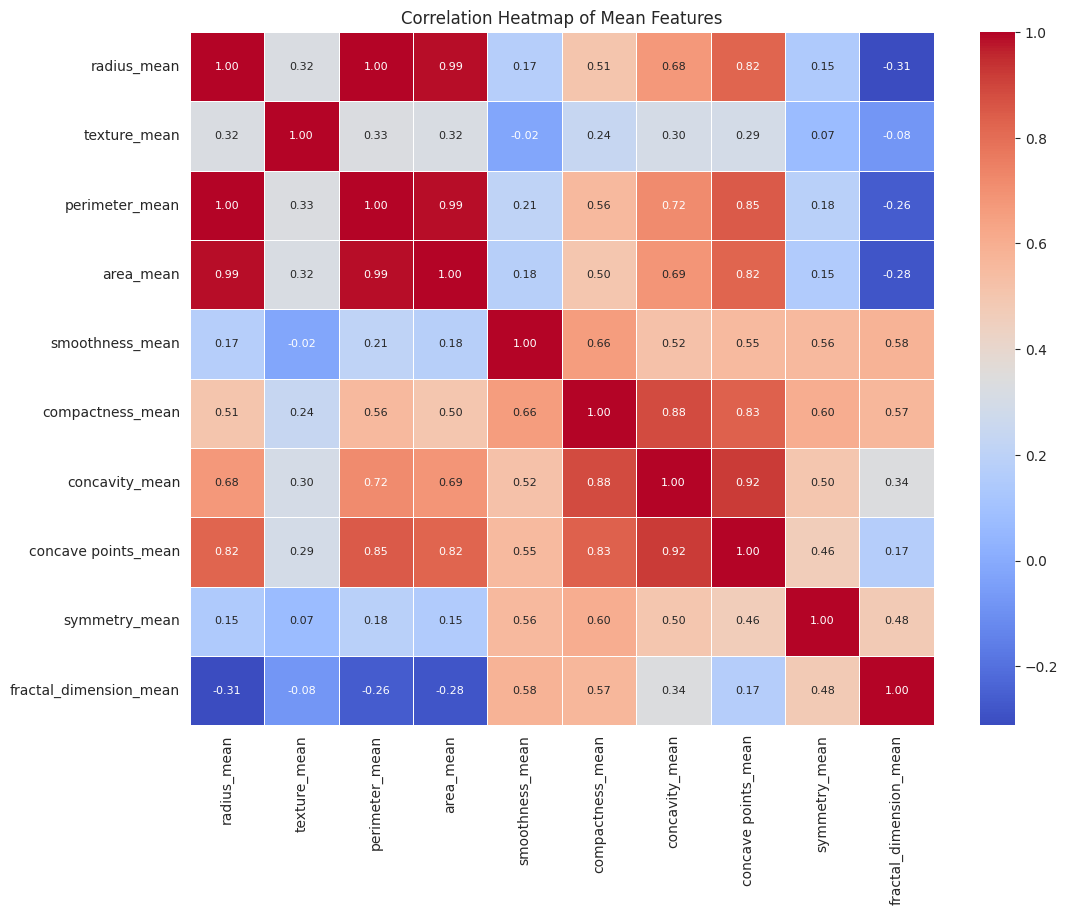

In [7]:
# Correlation heatmap for a subset of "mean" features
mean_cols = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(12, 9))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size': 8}, linewidths=0.5)
plt.title('Correlation Heatmap of Mean Features')
plt.show()


## 4. Clean and Preprocess the Data

- Drop the `id` column (not predictive).
- Drop any fully-empty "Unnamed" columns that sometimes appear in this dataset export.


In [8]:
# Drop id column if present
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Drop any unnamed/empty columns (common artifact in this dataset's CSV export)
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

df = df.dropna()  # drop any remaining rows with missing values
print("Shape after cleaning:", df.shape)


Shape after cleaning: (569, 31)


## 5. Encode the Target Variable

`diagnosis`: M (Malignant) → 1, B (Benign) → 0


In [9]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
print("Features shape:", X.shape)
print("Target shape:", y.shape)


{'B': np.int64(0), 'M': np.int64(1)}
Features shape: (569, 30)
Target shape: (569,)


## 6. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (455, 30)  Test size: (114, 30)


## 7. Feature Scaling

Logistic regression is sensitive to feature scale, so we standardize the features (mean=0, std=1) using the training set statistics.


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Train the Logistic Regression Model

In [12]:
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 9. Evaluate the Model

In [13]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9649


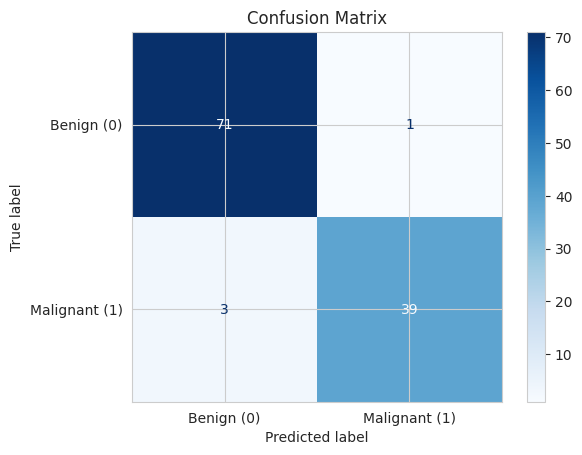

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [15]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



ROC-AUC Score: 0.9960


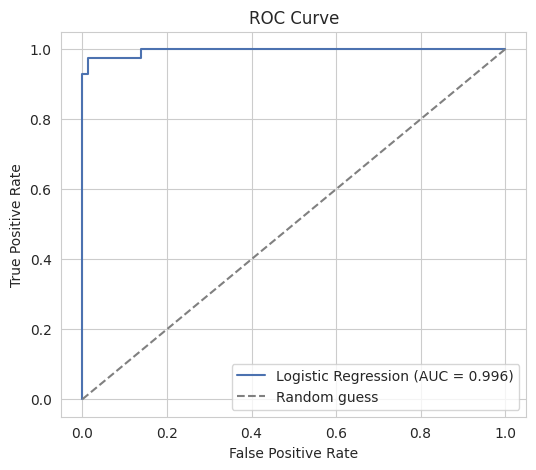

In [16]:
# ROC-AUC Score and ROC Curve
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', color='#4C72B0')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [17]:
# Cross-validation for a more robust performance estimate
cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='accuracy')
print("5-Fold CV Accuracy Scores:", np.round(cv_scores, 4))
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold CV Accuracy Scores: [0.9825 0.9825 0.9737 0.9737 0.9912]
Mean CV Accuracy: 0.9807 (+/- 0.0065)


## 10. Feature Importance (Model Coefficients)

Logistic regression coefficients indicate how strongly (and in which direction) each standardized feature influences the probability of malignancy.


/tmp/ipykernel_6202/2825096297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')


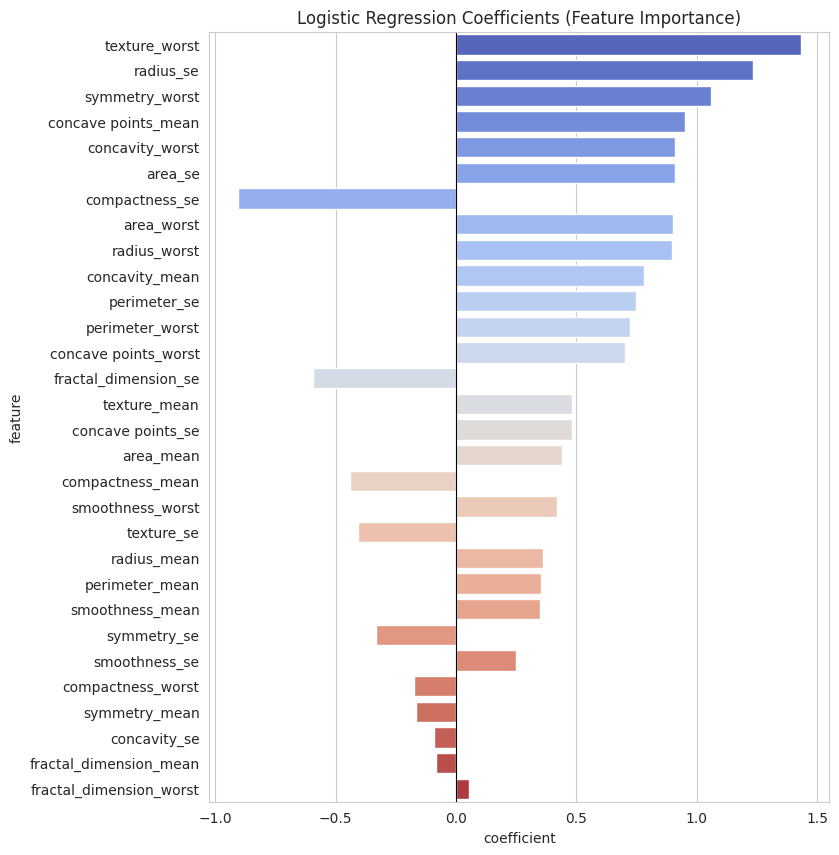

,feature,coefficient
21,texture_worst,1.434093
10,radius_se,1.233325
28,symmetry_worst,1.061264
7,concave points_mean,0.952813
26,concavity_worst,0.911406
13,area_se,0.909029
15,compactness_se,-0.906925
23,area_worst,0.900477
20,radius_worst,0.896968
6,concavity_mean,0.782298


In [18]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

coef_df.head(10)


## 11. Predict on a New/Sample Patient

Example: take the first row of the test set and show the predicted class vs. actual class.


In [19]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

pred_class = model.predict(sample_scaled)[0]
pred_proba = model.predict_proba(sample_scaled)[0][1]

print("Predicted class:", "Malignant" if pred_class == 1 else "Benign")
print(f"Probability of malignancy: {pred_proba:.4f}")
print("Actual class:", "Malignant" if y_test.iloc[0] == 1 else "Benign")


Predicted class: Benign
Probability of malignancy: 0.0004
Actual class: Benign


## Summary

- Loaded and cleaned the Wisconsin Breast Cancer dataset.
- Encoded the `diagnosis` target (M=1, B=0) and scaled the features.
- Trained a Logistic Regression classifier and evaluated it using accuracy, a confusion matrix, precision/recall/F1, ROC-AUC, and 5-fold cross-validation.
- Inspected which features most strongly drive the malignant/benign prediction.

Feel free to experiment with regularization strength (`C` parameter), different train/test splits, or feature selection to further improve performance.
